# Distillation Column Soft-Sensor
## Feature Scaling & ML Modeling

This notebook covers the complete machine learning pipeline:
- Feature scaling and preprocessing
- Baseline model development (Linear Regression)
- XGBoost model training and optimization
- Feature importance analysis
- Model comparison and evaluation
- Saving models for deployment

**Goal**: Build and compare multiple models to predict purity from process variables.

---
## Part 1: Setup & Data Loading

### 1.1 Import Libraries

In [59]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

import joblib

### 1.2 Configure Visualization Settings

In [60]:
# 1. Set Matplotlib figure size defaults (Width, Height in inches)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

# 2. Set Seaborn style and palette
sns.set_theme(style="whitegrid", palette="viridis")

# 3. Configure Pandas display settings for better readability
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.precision', 4)      # Round floats to 4 decimal places

### 1.3 Load Cleaned Data

In [61]:
from pathlib import Path

ROOT = Path.cwd().parent

DATA_DIR = ROOT / "data" 

X = pd.read_csv(DATA_DIR / 'X_ml_features.csv')
y = pd.read_csv(DATA_DIR / 'y_ml_target.csv')

In [62]:
print(X.shape)
print(y.shape)

(4168, 30)
(4168, 1)


In [63]:
X.head()

,hour_of_day_sin,T1_lag240,T4_lag1,T4_lag30,T5_lag240,T5,T4_lag60,hour_of_day_cos,L,F,T5_lag10,T5_lag30,T1_lag30,T5_lag1,T4_lag240,T1_lag60,T7,T6,T13,T4_lag10,B,T5_lag60,D,T1_lag10,T1,T4,T14,T5_lag5,T4_lag5,T1_lag5
0,0.0000,350.89,350.94,350.94,351.16,350.99,350.94,1.0000,780.0,600,350.99,350.99,350.82,350.99,351.08,350.82,351.14,351.06,354.75,350.94,340,350.99,260,350.82,350.82,350.94,362.92,350.99,350.94,350.82
1,0.0262,350.86,350.94,350.94,351.09,350.99,350.94,0.9997,780.0,600,350.99,350.99,350.82,350.99,351.02,350.82,351.14,351.06,354.75,350.94,340,350.99,260,350.82,350.82,350.94,362.92,350.99,350.94,350.82
2,0.0523,350.85,350.94,350.94,351.05,350.99,350.94,0.9986,780.0,600,350.99,350.99,350.82,350.99,350.99,350.82,351.14,351.06,354.75,350.94,340,350.99,260,350.82,350.82,350.94,362.92,350.99,350.94,350.82
3,0.0785,350.84,350.94,350.94,351.03,350.99,350.94,0.9969,780.0,600,350.99,350.99,350.82,350.99,350.97,350.82,351.14,351.06,354.75,350.94,340,350.99,260,350.82,350.82,350.94,362.92,350.99,350.94,350.82
4,0.1045,350.83,350.94,350.94,351.02,350.99,350.94,0.9945,780.0,600,350.99,350.99,350.82,350.99,350.96,350.82,351.14,351.06,354.75,350.94,340,350.99,260,350.82,350.82,350.94,362.92,350.99,350.94,350.82


In [64]:
y.head()

,Ethanol concentration
0,0.8514
1,0.8514
2,0.8514
3,0.8514
4,0.8514


In [65]:
X.isnull().sum()

hour_of_day_sin    0
T1_lag240          0
T4_lag1            0
T4_lag30           0
T5_lag240          0
T5                 0
T4_lag60           0
hour_of_day_cos    0
L                  0
F                  0
T5_lag10           0
T5_lag30           0
T1_lag30           0
T5_lag1            0
T4_lag240          0
T1_lag60           0
T7                 0
T6                 0
T13                0
T4_lag10           0
B                  0
T5_lag60           0
D                  0
T1_lag10           0
T1                 0
T4                 0
T14                0
T5_lag5            0
T4_lag5            0
T1_lag5            0
dtype: int64

In [66]:
#Extract features names
features_names = X.columns.to_list()

In [67]:
# Find min/max/median values for each feature:

summary = pd.DataFrame({
    'min': X.min(),
    'max': X.max(),
    'default': X.median() 
})

variable_dict = summary.to_dict(orient='index')

variable_dict

{'hour_of_day_sin': {'min': -1.0, 'max': 1.0, 'default': 0.0261769483078791},
 'T1_lag240': {'min': 350.76, 'max': 352.32, 'default': 350.9},
 'T4_lag1': {'min': 350.79, 'max': 368.6, 'default': 351.32},
 'T4_lag30': {'min': 350.79, 'max': 368.6, 'default': 351.31},
 'T5_lag240': {'min': 350.8, 'max': 369.06, 'default': 351.51},
 'T5': {'min': 350.8, 'max': 369.06, 'default': 351.62},
 'T4_lag60': {'min': 350.79, 'max': 368.6, 'default': 351.3},
 'hour_of_day_cos': {'min': -1.0,
  'max': 1.0,
  'default': 6.123233995736766e-17},
 'L': {'min': 75.0, 'max': 1950.0, 'default': 780.0},
 'F': {'min': 350.0, 'max': 650.0, 'default': 600.0},
 'T5_lag10': {'min': 350.8, 'max': 369.06, 'default': 351.61},
 'T5_lag30': {'min': 350.8, 'max': 369.06, 'default': 351.6},
 'T1_lag30': {'min': 350.76, 'max': 352.32, 'default': 350.91},
 'T5_lag1': {'min': 350.8, 'max': 369.06, 'default': 351.62},
 'T4_lag240': {'min': 350.79, 'max': 368.6, 'default': 351.27},
 'T1_lag60': {'min': 350.76, 'max': 352.32

In [68]:
target_name = y.columns[0]
target_name

'Ethanol concentration'

---
## Part 2: Train/Test Split

In [69]:
lenght = len(X)

X_train = X.iloc[:int(lenght*0.8)]
X_test = X.iloc[int(lenght*0.8):]

y_train = y.iloc[:int(lenght*0.8)]
y_test = y.iloc[int(lenght*0.8):]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3334, 30), (834, 30), (3334, 1), (834, 1))

---
## Part 3: Feature Scaling

#### 3.1 Choose and Fit Scaler

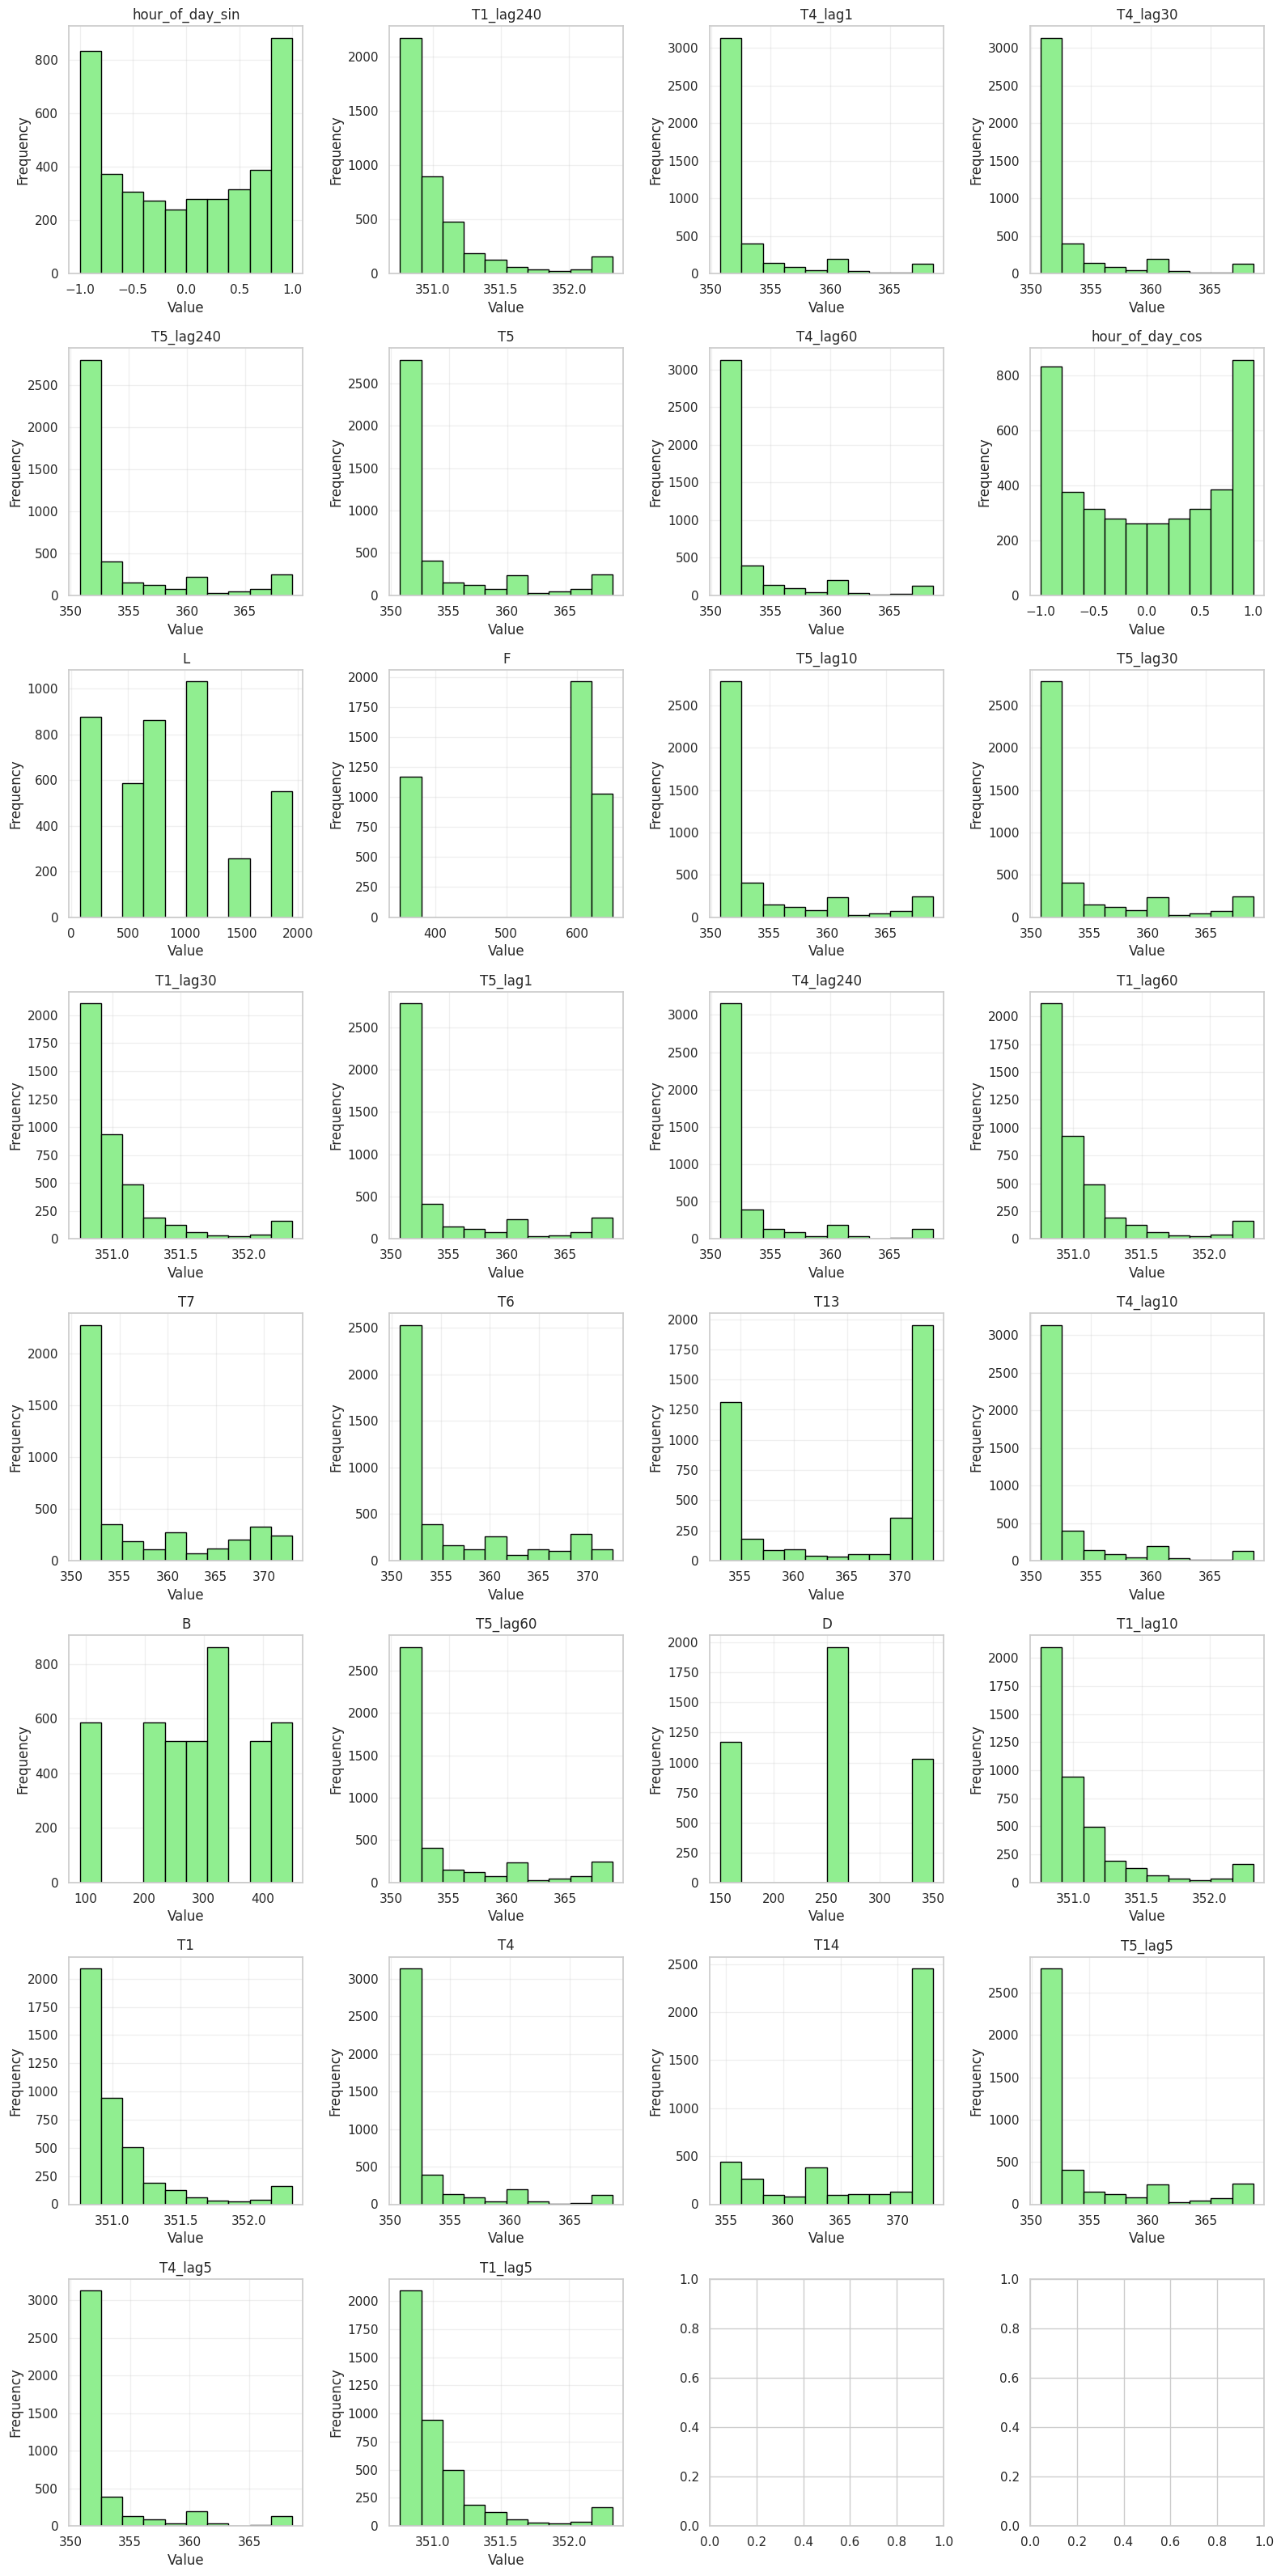

In [70]:
# Plot distributions of all features (excluding time_hours for clarity)
feature_cols_to_plot = [col for col in X.columns]
n_features = len(feature_cols_to_plot)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

for idx, col in enumerate(feature_cols_to_plot):
    axes[idx].hist(X[col], color='lightgreen', edgecolor='black')
    axes[idx].set_title(f'{col}')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(alpha=0.3)


plt.tight_layout()
plt.show()

In [71]:
features_time = ['hour_of_day_sin', 'hour_of_day_cos'] # no scaling
features_minmax = ['L', 'F', 'B', 'D'] # min max scaling
features_robust = list(set(X.columns) - set(features_time) - set(features_minmax))  # robust scaling

In [72]:
preprocessor = ColumnTransformer(
    transformers=[
        ('robust_scaler', RobustScaler(), features_robust),
        ('minmax_scaler', MinMaxScaler(), features_minmax)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')
pipe_preprocess = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

pipe_preprocess

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('robust_scaler', ...), ('minmax_scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [73]:
X_train_scaled = pipe_preprocess.fit_transform(X_train)
X_test_scaled = pipe_preprocess.transform(X_test)

In [74]:
X_train_scaled.describe()

,T4_lag60,T4_lag1,T5_lag240,T4_lag10,T5_lag1,T5,T1_lag5,T4_lag30,T5_lag30,T7,T4_lag5,T13,T5_lag10,T1_lag60,T1_lag10,T14,T6,T5_lag60,T4_lag240,T1,T4,T1_lag240,T5_lag5,T1_lag30,L,F,B,D,hour_of_day_sin,hour_of_day_cos
count,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3.3340e+03,3.3340e+03
mean,1.1991,1.1491,1.1331,1.1410,0.9356,0.9356,0.4929,1.1530,0.9622,0.3683,1.1490,-0.3505,0.9317,0.5187,0.4925,-0.5020,0.5919,0.9940,1.2988,0.4931,1.1491,0.5613,0.9355,0.5252,0.3985,0.6323,0.5578,0.4944,2.6474e-03,-7.1762e-03
std,2.8373,2.7365,2.3272,2.7180,1.9535,1.9535,1.3042,2.7428,1.9990,0.6591,2.7366,0.4834,1.9461,1.3078,1.3044,0.6760,1.1299,2.0509,3.0355,1.3041,2.7365,1.3162,1.9535,1.3058,0.2927,0.4057,0.3070,0.3757,7.0914e-01,7.0523e-01
min,-0.3191,-0.3288,-0.2442,-0.3265,-0.2821,-0.2821,-0.5556,-0.3225,-0.2767,-0.1590,-0.3288,-1.0023,-0.2810,-0.5185,-0.5556,-1.8147,-0.2083,-0.2675,-0.2803,-0.5556,-0.3288,-0.4444,-0.2821,-0.5185,0.0000,0.0000,0.0000,0.0000,-1.0000e+00,-1.0000e+00
25%,-0.2057,-0.2123,-0.1567,-0.2177,-0.1971,-0.1971,-0.2963,-0.2127,-0.1937,-0.1264,-0.2123,-0.9117,-0.2002,-0.2593,-0.2963,-0.9822,-0.1565,-0.1824,-0.1667,-0.2963,-0.2123,-0.2222,-0.1971,-0.2593,0.2000,0.0000,0.3056,0.0000,-7.0711e-01,-7.0711e-01
50%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3760,0.8333,0.5833,0.5500,1.2246e-16,-1.8370e-16
75%,0.7943,0.7877,0.8433,0.7823,0.8029,0.8029,0.7037,0.7873,0.8063,0.8736,0.7877,0.0883,0.7998,0.7407,0.7037,0.0178,0.8435,0.8176,0.8333,0.7037,0.7877,0.7778,0.8029,0.7407,0.5200,0.8333,0.8333,1.0000,7.0711e-01,6.8835e-01
max,12.3121,11.8699,8.1705,11.7891,6.7749,6.7749,5.2222,11.8971,6.9407,1.9588,11.8699,0.1251,6.7488,5.2593,5.2222,0.0238,3.8194,7.1327,13.2121,5.2222,11.8699,5.3333,6.7749,5.2593,1.0000,1.0000,1.0000,1.0000,1.0000e+00,1.0000e+00


#### 3.2 Save the Scaler

In [75]:
joblib.dump(pipe_preprocess, ROOT / "models" / "scaler.pkl")

['/home/ildebrando/code/ijesusjr/000_DS_Portfolio/01_soft_sensor/models/scaler.pkl']

## Part 4: Baseline Model

### 4.1 Linear Regression Baseline

In [76]:
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [77]:
# 1. Get predictions
y_pred_lr = lr_model.predict(X_test_scaled)

# 2. Calculate metrics
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = root_mean_squared_error(y_test, y_pred_lr)

print(f"R2 Score: {r2_lr:.4f}")
print(f"Mean Error: {mae_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")

R2 Score: 0.9859
Mean Error: 0.0062
RMSE: 0.0080


In [78]:
# Checking the order of importance of the features

coef_df_lr = pd.DataFrame({
    'Feature': lr_model.feature_names_in_,
    'Coefficient': lr_model.coef_.flatten()
})

coef_df_lr['Abs_Coefficient'] = coef_df_lr['Coefficient'].abs()
coef_df_lr = coef_df_lr.sort_values(by='Abs_Coefficient', ascending=False)

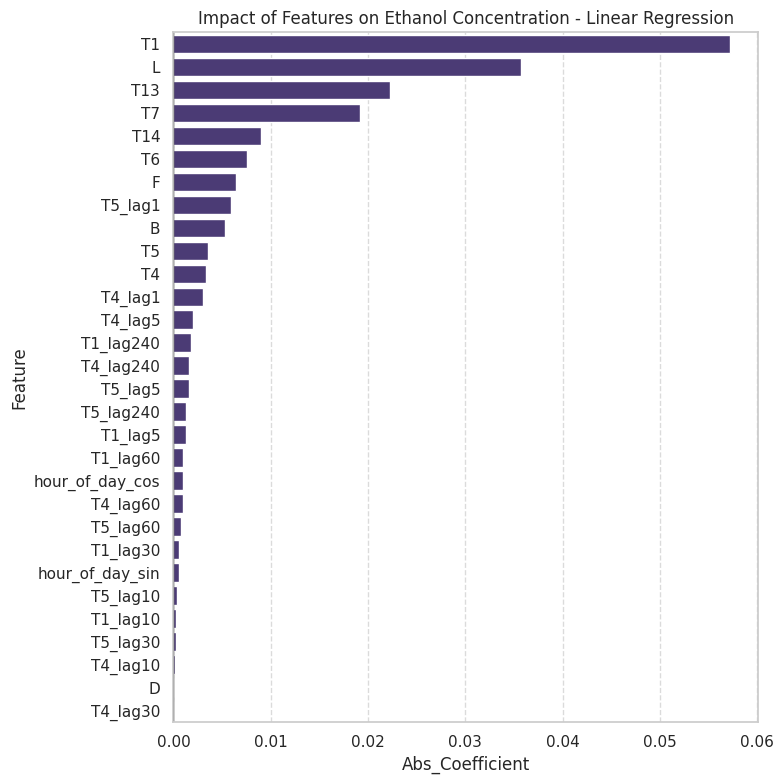

In [79]:
plt.figure(figsize=(8, 8))

sns.barplot(
    data=coef_df_lr, 
    x='Abs_Coefficient', 
    y='Feature', 
    legend=False
)

# Add a vertical line at 0 for clarity
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)

plt.title('Impact of Features on Ethanol Concentration - Linear Regression', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---
## Part 5: XGBoost Model

### 5.1 Train XGBoost (Basic Configuration)

In [80]:
xgb_reg = XGBRegressor()

xgb_reg.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_reg.predict(X_test_scaled)

In [81]:
r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)

print(f"R2 Score: {r2_xgb:.4f}")
print(f"Mean Error: {mae_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")

R2 Score: 0.9998
Mean Error: 0.0008
RMSE: 0.0010


---
## Part 6: Feature Importance Analysis

### 6.1 Extract and Visualize Feature Importance

In [82]:
coef_df_xgb = pd.DataFrame({
    'Feature': xgb_reg.feature_names_in_,
    'Importance': xgb_reg.feature_importances_
})

coef_df_xgb = coef_df_xgb.sort_values(by='Importance', ascending=False)

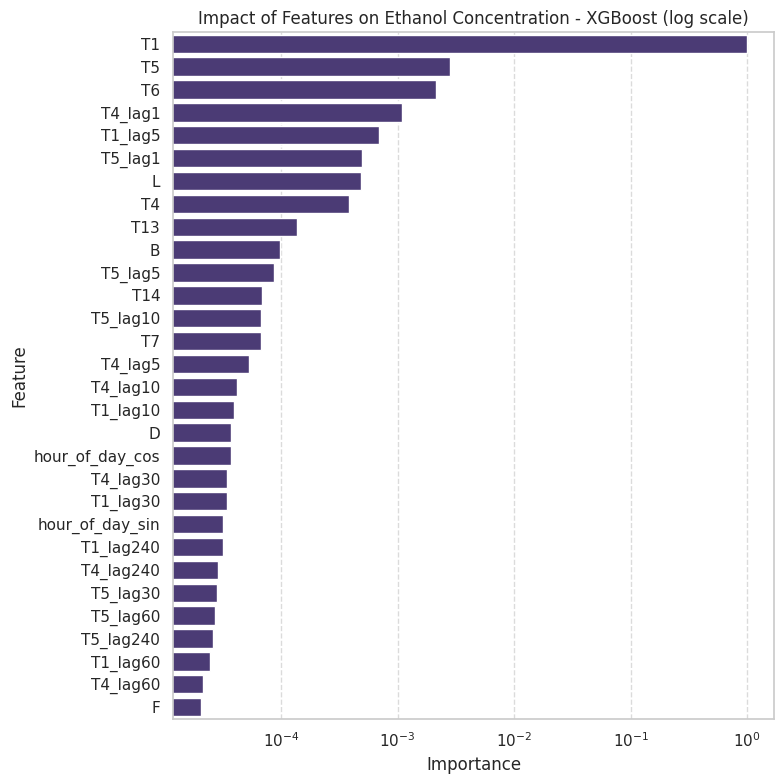

In [83]:
plt.figure(figsize=(8, 8))

sns.barplot(
    data=coef_df_xgb, 
    x='Importance', 
    y='Feature', 
    legend=False
)

plt.xscale('log')

plt.title('Impact of Features on Ethanol Concentration - XGBoost (log scale)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---
## Part 7: Model Comparison & Visualization

### 7.1 Model Comparison


In [84]:
comparison_df =  pd.DataFrame({"Linear Regression" : [r2_lr, mae_lr, rmse_lr],
                                "XGBoost" : [r2_xgb, mae_xgb, rmse_xgb],
                                "Improvement (%)" : [abs(((r2_xgb-r2_lr)/r2_lr)*100), 
                                                     abs(((mae_xgb-mae_lr)/mae_lr)*100), 
                                                     abs(((rmse_xgb-rmse_lr)/rmse_lr)*100)]},
                                index = ['r2', 'MAE', 'RMSE'])
comparison_df['Improvement (%)'] = comparison_df['Improvement (%)'].round(2)
comparison_df

,Linear Regression,XGBoost,Improvement (%)
r2,0.9859,0.9998,1.41
MAE,0.0062,0.0008,87.62
RMSE,0.0080,0.0010,87.34


#### Some insights:
- Linear Regression achieved R² = 0.9859, showing a strong linear relationship with purity. XGBoost achieved R² = 0.9998, indicating it captures non-linear patterns and feature interactions that Linear Regression misses.
- Feature importance analysis reveals T1 as the dominant predictor in both models, though XGBoost assigns it higher importance due to its ability to model non-linear thresholds and interactions.
- These results indicates that stage where T1 is measured in the sensitive tray, the one that ensures tighter control of the distillate purity.

### 7.2 Visualize Predictions vs Actual

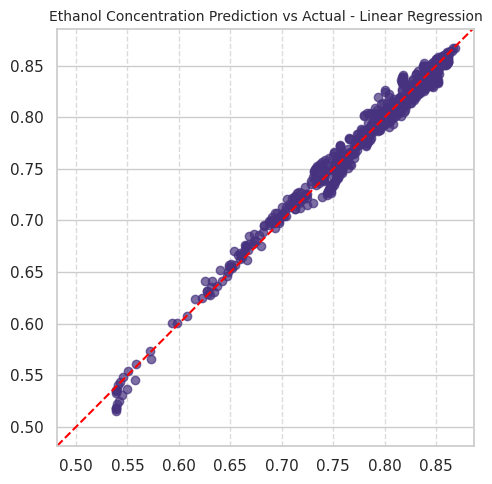

In [85]:
plt.figure(figsize=(5, 5))

plt.scatter(x=y_test, y=y_pred_lr, alpha=0.7)
plt.axline((0.5, 0.5), slope=1, color='red', linestyle='--', label='Ideal (x=y)')
plt.title('Ethanol Concentration Prediction vs Actual - Linear Regression', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

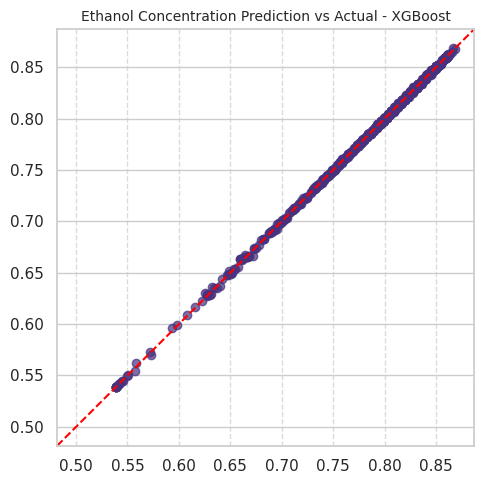

In [86]:
plt.figure(figsize=(5, 5))

plt.scatter(x=y_test, y=y_pred_xgb, alpha=0.7)
plt.axline((0.5, 0.5), slope=1, color='red', linestyle='--', label='Ideal (x=y)')
plt.title('Ethanol Concentration Prediction vs Actual - XGBoost', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 7.3 Analyze Residuals

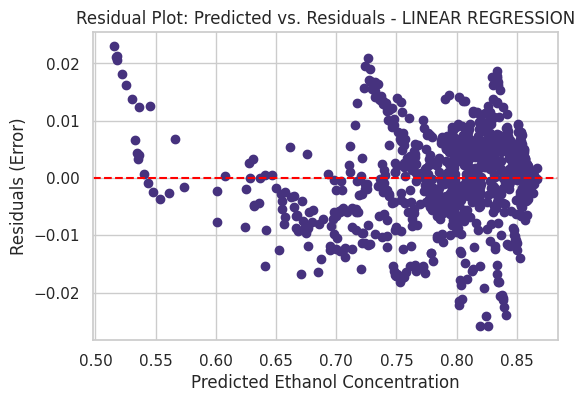

In [87]:
# 1. Calculate residuals
residuals_lr = y_test - y_pred_lr

# 2. Plot
plt.figure(figsize=(6, 4))
plt.scatter(y_pred_lr, residuals_lr)
plt.axhline(y=0, color='red', linestyle='--') 
plt.title('Residual Plot: Predicted vs. Residuals - LINEAR REGRESSION')
plt.xlabel('Predicted Ethanol Concentration')
plt.ylabel('Residuals (Error)')
plt.show()

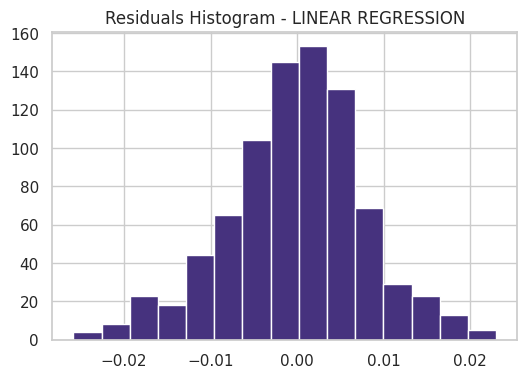

In [88]:
plt.figure(figsize=(6, 4))
plt.hist(residuals_lr, bins=15)
plt.title('Residuals Histogram - LINEAR REGRESSION')
plt.show()

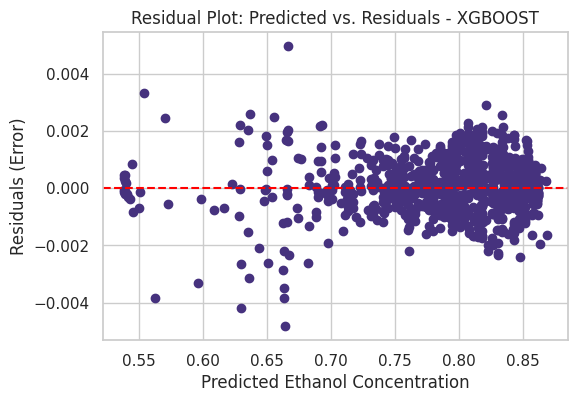

In [89]:
# 1. Calculate residuals
residuals_xgb = y_test.values.flatten() - y_pred_xgb.flatten()

# 2. Plot
plt.figure(figsize=(6, 4))
plt.scatter(y_pred_xgb, residuals_xgb)
plt.axhline(y=0, color='red', linestyle='--') 
plt.title('Residual Plot: Predicted vs. Residuals - XGBOOST')
plt.xlabel('Predicted Ethanol Concentration')
plt.ylabel('Residuals (Error)')
plt.show()

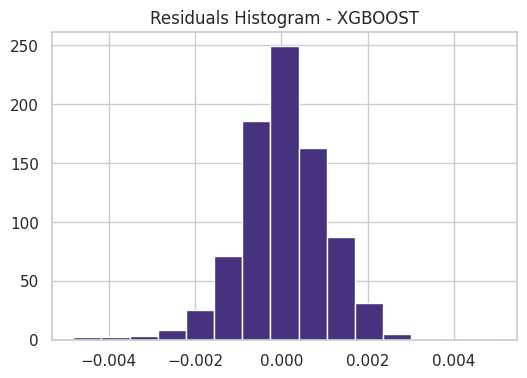

In [90]:
plt.figure(figsize=(6, 4))
plt.hist(residuals_xgb, bins=15)
plt.title('Residuals Histogram - XGBOOST')
plt.show()

**Some observations:**
- The residuals are randomly distributed 
- The residuals are larger at lower concentracions, reflecting the skewness of the target distribution, bu not impacting the performance of the model significantly
- Specially in the linear regression case, the residuals are skewed following the same pattern of the target distribution

### 7.4 Final Model Selection

- Model chosen to deploy: **XGBoost**, because it has a overall better performance and can capture the non-linear patterns of the operation

---
## Part 8: Save Models & Preprocessing Objects

### 8.1 Save Best Models for Deployment

In [91]:
joblib.dump(lr_model, ROOT / "models" / "lr_model.pkl")
joblib.dump(xgb_reg, ROOT / "models" / "xgb_model.pkl")

['/home/ildebrando/code/ijesusjr/000_DS_Portfolio/01_soft_sensor/models/xgb_model.pkl']

### 8.2 Verify Saved Objects

In [92]:
# Loading models
scaler_test = joblib.load(ROOT / "models" / "scaler.pkl")
model_lr_test = joblib.load(ROOT / "models" / "lr_model.pkl")
model_xgb_test = joblib.load(ROOT / "models" / "xgb_model.pkl")


In [93]:
X_new = X_test.iloc[100:200]
y_new = y_test[100:200]

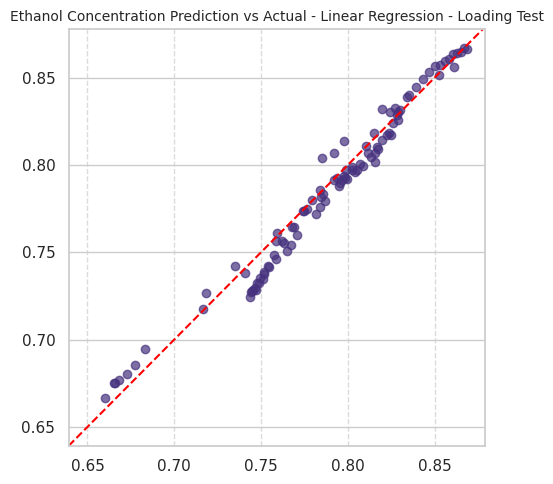

In [94]:
# Testing the loaded models with a fraction of test set

X_new_scaled = scaler_test.transform(X_new)
y_pred_lr_new = model_lr_test.predict(X_new_scaled)

plt.figure(figsize=(5, 5))

plt.scatter(x=y_new, y=y_pred_lr_new, alpha=0.7)
plt.axline((0.65, 0.65), slope=1, color='red', linestyle='--', label='Ideal (x=y)')
plt.title('Ethanol Concentration Prediction vs Actual - Linear Regression - Loading Test', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()